# MT sentenceith GRU

In [7]:
!rm ita-eng.zip &> /dev/null
!rm rm -rf dataset &> /dev/null
!wget "https://www.manythings.org/anki/ita-eng.zip" &> /dev/null
!unzip "ita-eng.zip" -d "dataset" &> /dev/null

text_file = "dataset/ita.txt"

In [8]:
! pip install numpy tensorflow[and-cuda] scikit-learn matplotlib

  Using cached nvidia_cublas_cu12-12.2.5.6-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.2.142-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cuda_nvcc_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cudnn_cu12-8.9.4.25-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cufft_cu12-11.0.8.103-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.3.141-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.5.2.141-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.2.141-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.16.5-py3-none-manyl

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.15.0
NumPy version: 1.26.4
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import re
from typing import List, Tuple

import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, Embedding, GRU, Dense
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time



In [3]:
! ls

dataset  ita-eng.zip  sample_data


### Dataset

In [ ]:
DATASET_FILE = "./dataset/ita.txt"

def preprocess_sentence(w):
    w = w.lower().strip()
    w = re.sub(r"([?.!,¿])", r" \1 ", w)
    w = re.sub(r'[" "]+', " ", w)
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)
    w = w.strip()
    w = '<start> ' + w + ' <end>'
    return w

def create_dataset(path, num_examples):
    lines = open(path, encoding='UTF-8').read().strip().split('\n')
    word_pairs = [[preprocess_sentence(w) for w in l.split('\t')[:2]]  for l in lines[:num_examples]]
    return zip(*word_pairs)

In [5]:
input_text, target_text = create_dataset(DATASET_FILE, 84_000)
print(list(zip(input_text[:5], target_text[:5])))
print(len(input_text))

[('<start> hi . <end>', '<start> ciao ! <end>'), ('<start> hi . <end>', '<start> ciao . <end>'), ('<start> run ! <end>', '<start> corri ! <end>'), ('<start> run ! <end>', '<start> corra ! <end>'), ('<start> run ! <end>', '<start> correte ! <end>')]
84000


### Training

#### Device definition

In [8]:
mps_available = len(tf.config.list_physical_devices('GPU')) > 0
device_path = '/GPU:0' if mps_available else '/CPU:0'
device_name = 'MPS (M3 Neural Engine)' if mps_available else 'CPU'
print(tf.config.list_physical_devices())
device_path

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


'/GPU:0'

#### Tokenization

In [ ]:
def tokenize(lang):
  lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
  lang_tokenizer.fit_on_texts(lang)
  tensor = lang_tokenizer.texts_to_sequences(lang)
  tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')
  return tensor, lang_tokenizer

input_tensor, input_lang_tokenizer = tokenize(input_text)
target_tensor, target_lang_tokenizer = tokenize(target_text)

max_length_targ = target_tensor.shape[1]
max_length_inp = input_tensor.shape[1]

input_tensor_temp, input_tensor_test, target_tensor_temp, target_tensor_test = train_test_split(
    input_tensor, target_tensor, test_size=0.2, random_state=42
)

input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(
    input_tensor_temp, target_tensor_temp, test_size=0.25, random_state=42
)
vocab_inp_size = len(input_lang_tokenizer.word_index)+1
vocab_tar_size = len(target_lang_tokenizer.word_index)+1

#### Hyperparameters

In [ ]:
BATCH_SIZE = 128
EPOCHS = 30
EMBEDDING_DIM = 256
UNITS = 512

### Model

#### Encoder

In [22]:
class Encoder(Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super(Encoder, self).__init__()
        self.enc_units = enc_units
        self.embedding = Embedding(vocab_size, embedding_dim)
        self.gru = GRU(self.enc_units,
                       return_sequences=True,
                       return_state=True,
                       recurrent_initializer='glorot_uniform')

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.gru(x, initial_state=hidden)
        return output, state

#### Bahdanau Attention

In [ ]:
class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)

        query_transformed = self.W1(query_with_time_axis)
        values_transformed = self.W2(values)

        combined = query_transformed + values_transformed

        score = self.V(tf.nn.tanh(combined))

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

#### Decoder

In [ ]:
class Decoder(Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super(Decoder, self).__init__()
        self.dec_units = dec_units
        self.embedding = Embedding(vocab_size, embedding_dim)
        self.gru = GRU(self.dec_units,
                       return_sequences=True,
                       return_state=True,
                       recurrent_initializer='glorot_uniform')
        self.fc = Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)

        x = self.embedding(x)

        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)

        output = tf.reshape(output, (-1, output.shape[2]))

        x = self.fc(output)

        return x, state, attention_weights

### Training

In [25]:
buffer_size = len(input_tensor_train)
steps_per_epoch = buffer_size // EPOCHS

dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train)).shuffle(buffer_size)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

encoder = Encoder(vocab_inp_size, EMBEDDING_DIM, UNITS)
decoder = Decoder(vocab_tar_size, EMBEDDING_DIM, UNITS)

optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

In [26]:
checkpoint_dir = 'training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer,
                                 encoder=encoder,
                                 decoder=decoder)

In [27]:
def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

In [ ]:
@tf.function
def train_step(inp, targ):
    with tf.device(device_path):
        loss = tf.constant(0.0, dtype=tf.float32)
        enc_hidden = tf.zeros((BATCH_SIZE, UNITS))

        with tf.GradientTape() as tape:
            enc_output, enc_hidden = encoder(inp, enc_hidden)
            dec_hidden = enc_hidden
            start_token = target_lang_tokenizer.word_index['<start>']
            dec_input = tf.fill([BATCH_SIZE, 1], start_token)

            for t in tf.range(1, tf.shape(targ)[1]):
                predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
                loss += loss_function(targ[:, t], predictions)
                dec_input = tf.expand_dims(targ[:, t], 1)

        target_sequence_length = tf.cast(tf.shape(targ)[1], tf.float32)
        if target_sequence_length > 0:
            batch_loss = loss / target_sequence_length
        else:
            batch_loss = tf.constant(0.0, dtype=tf.float32)


        variables = encoder.trainable_variables + decoder.trainable_variables
        gradients = tape.gradient(loss, variables)
        optimizer.apply_gradients(zip(gradients, variables))
        return batch_loss

In [ ]:
def evaluate_model(sentence):
    attention_plot = np.zeros((max_length_targ, max_length_inp))

    sentence = sentence.lstrip("<start>").rstrip("<end>")
    sentence = preprocess_sentence(sentence)
    inputs = [input_lang_tokenizer.word_index.get(i, 0) for i in sentence.split(' ')]
    inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs],
                                                          maxlen=max_length_inp,
                                                          padding='post')
    inputs = tf.convert_to_tensor(inputs, dtype=tf.int64)

    result = ''
    hidden = tf.zeros((1, UNITS))
    enc_out, enc_hidden = encoder(inputs, hidden)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([target_lang_tokenizer.word_index['<start>']], 0)

    for t in range(max_length_targ):
        predictions, dec_hidden, attention_weights = decoder(dec_input,
                                                             dec_hidden,
                                                             enc_out)

        attention_weights = tf.reshape(attention_weights, (-1, ))
        attention_plot[t] = attention_weights.numpy()

        predicted_id = tf.argmax(predictions[0]).numpy()
        result += target_lang_tokenizer.index_word[predicted_id] + ' '

        if target_lang_tokenizer.index_word[predicted_id] == '<end>':
            result += '<end>'
            return result, sentence, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence, attention_plot

In [ ]:
def validate_model(val_dataset, val_steps):
    total_val_loss = 0
    val_batches = 0

    for (inp, targ) in val_dataset.take(val_steps):
        batch_size = tf.shape(inp)[0]
        enc_hidden = tf.zeros((batch_size, UNITS))

        enc_output, enc_hidden = encoder(inp, enc_hidden, training=False)
        dec_hidden = enc_hidden
        dec_input = tf.fill([batch_size, 1], target_lang_tokenizer.word_index['<start>'])

        val_loss = 0
        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output, training=False)
            val_loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)

        batch_val_loss = val_loss / targ.shape[1]
        total_val_loss += batch_val_loss
        val_batches += 1

    return total_val_loss / val_batches

In [ ]:
val_dataset = tf.data.Dataset.from_tensor_slices((input_tensor_val, target_tensor_val))
val_dataset = val_dataset.batch(BATCH_SIZE)
val_steps = len(input_tensor_val) // BATCH_SIZE

total_time = 0
best_val_loss = float('inf')
patience = 5
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    total_loss = 0

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 50)

    print("Training...")
    for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
        batch_loss = train_step(inp, targ)
        total_loss += batch_loss

        if batch % 10 == 0:
            print(f'Batch {batch} Loss {batch_loss.numpy():.4f}')

    avg_train_loss = total_loss / steps_per_epoch
    train_losses.append(avg_train_loss.numpy())

    print("\nValidating...")
    val_loss = validate_model(val_dataset, val_steps)
    val_losses.append(val_loss.numpy())

    epoch_time = time.time() - start
    total_time += epoch_time

    print(f'\nEpoch {epoch} Results:')
    print(f'Training Loss: {avg_train_loss:.4f}')
    print(f'Validation Loss: {val_loss:.4f}')
    print(f'Time taken: {epoch_time:.2f} sec')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        print(f"✓ New best validation loss: {best_val_loss:.4f}")
        checkpoint.save(file_prefix=checkpoint_prefix + "_best")
    else:
        patience_counter += 1
        print(f"Validation loss did not improve. Patience: {patience_counter}/{patience}")

    if epoch % 2 == 0:
        checkpoint.save(file_prefix=checkpoint_prefix)

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}. Validation loss hasn't improved for {patience} epochs.")
        break

    print("=" * 60)

print(f'\nTraining completed!')
print(f'Total time taken: {total_time:.2f} sec')
print(f'Best validation loss: {best_val_loss:.4f}')

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)


Epoch 1/30
--------------------------------------------------
Training...
Batch 0 Loss 2.5515
Batch 10 Loss 1.4870
Batch 20 Loss 1.5385
Batch 30 Loss 1.5304
Batch 40 Loss 1.4010
Batch 50 Loss 1.4002
Batch 60 Loss 1.3690
Batch 70 Loss 1.3314
Batch 80 Loss 1.2657
Batch 90 Loss 1.2613
Batch 100 Loss 1.2952
Batch 110 Loss 1.2588
Batch 120 Loss 1.2459
Batch 130 Loss 1.1711
Batch 140 Loss 1.1796
Batch 150 Loss 1.1854
Batch 160 Loss 1.2352
Batch 170 Loss 1.2184
Batch 180 Loss 1.1513
Batch 190 Loss 1.1682
Batch 200 Loss 1.1229
Batch 210 Loss 1.1179
Batch 220 Loss 1.1236
Batch 230 Loss 1.1202
Batch 240 Loss 1.1691
Batch 250 Loss 1.0789
Batch 260 Loss 1.0960
Batch 270 Loss 1.1438
Batch 280 Loss 1.1095
Batch 290 Loss 1.0855
Batch 300 Loss 1.0498
Batch 310 Loss 1.1109
Batch 320 Loss 1.1070
Batch 330 Loss 1.0279
Batch 340 Loss 1.0960
Batch 350 Loss 1.0471
Batch 360 Loss 1.1039
Batch 370 Loss 1.0749
Batch 380 Loss 1.0480
Batch 390 Loss 1.0106

Validating...

Epoch 1 Results:
Training Loss: 0.2853
V

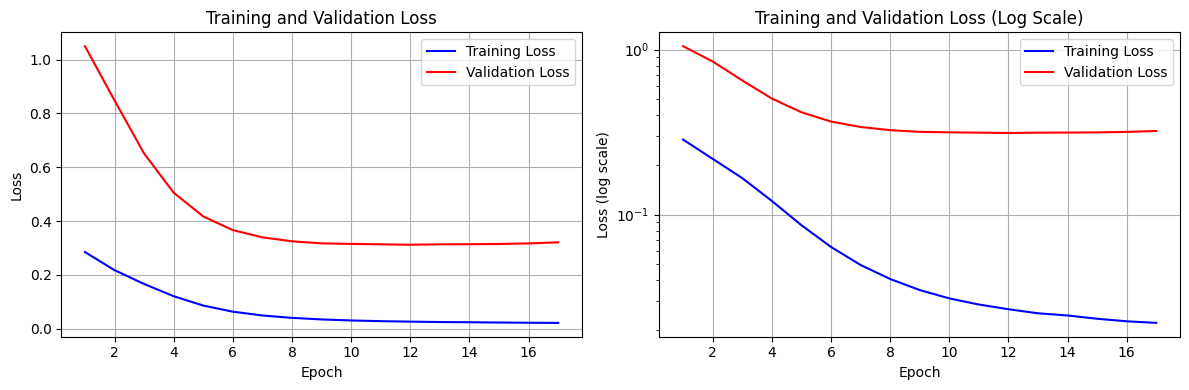

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss (Log Scale)')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices((input_tensor_test, target_tensor_test))
test_dataset = test_dataset.batch(BATCH_SIZE)
test_steps = len(input_tensor_test) // BATCH_SIZE

print("Evaluating on test set...")
test_loss = validate_model(test_dataset, test_steps)
print(f'Test Loss: {test_loss:.4f}')

print("\nSample Test Translations:")
print("-" * 40)
for i in range(min(10, len(input_tensor_test))):
    input_sentence = ' '.join([input_lang_tokenizer.index_word.get(idx, '<UNK>')
                              for idx in input_tensor_test[i] if idx != 0])
    target_sentence = ' '.join([target_lang_tokenizer.index_word.get(idx, '<UNK>')
                               for idx in target_tensor_test[i] if idx != 0])

    try:
        result, _, _ = evaluate_model(input_sentence)
        print(f"Input: {input_sentence}")
        print(f"Target: {target_sentence}")
        print(f"Predicted: {result.strip()}")
        print("-" * 40)
    except Exception as e:
        print(f"Error translating test sentence {i}: {e}")
        print("-" * 40)

Evaluating on test set...
Test Loss: 0.3221

Sample Test Translations:
----------------------------------------
Input: <start> we re smashed . <end>
Target: <start> siamo sbronzi . <end>
Predicted: siamo ubriache . <end> <end>
----------------------------------------
Input: <start> nice seeing you ! <end>
Target: <start> bello vedervi ! <end>
Predicted: bello vederla ! <end> <end>
----------------------------------------
Input: <start> don t look so sad . <end>
Target: <start> non sembrare cos triste . <end>
Predicted: non sembrate cos tristi . <end> <end>
----------------------------------------
Input: <start> tom visited boston . <end>
Target: <start> tom ha visitato boston . <end>
Predicted: tom ha lasciato boston . <end> <end>
----------------------------------------
Input: <start> we ll find them . <end>
Target: <start> li troveremo . <end>
Predicted: noi li troveremo . <end> <end>
----------------------------------------
Input: <start> there is no water . <end>
Target: <start> no

In [ ]:
def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    clean_sentence = [s for s in sentence]
    ax.set_xticklabels([''] + clean_sentence, fontdict=fontdict, rotation=90)

    clean_predicted_sentence = [s for s in predicted_sentence]
    ax.set_yticklabels([''] + clean_predicted_sentence, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title('Attention Weights')
    plt.xlabel('Input Sentence')
    plt.ylabel('Predicted Sentence')
    plt.tight_layout()
    plt.show()

['<start>', 'tom', 'likes', 'espresso', '.', '<end>'] ['<start>', 'a', 'tom', 'piace', 'l', 'espresso', '.', '<end>']


/tmp/ipython-input-34-3222043029.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + clean_sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-34-3222043029.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + clean_predicted_sentence, fontdict=fontdict)


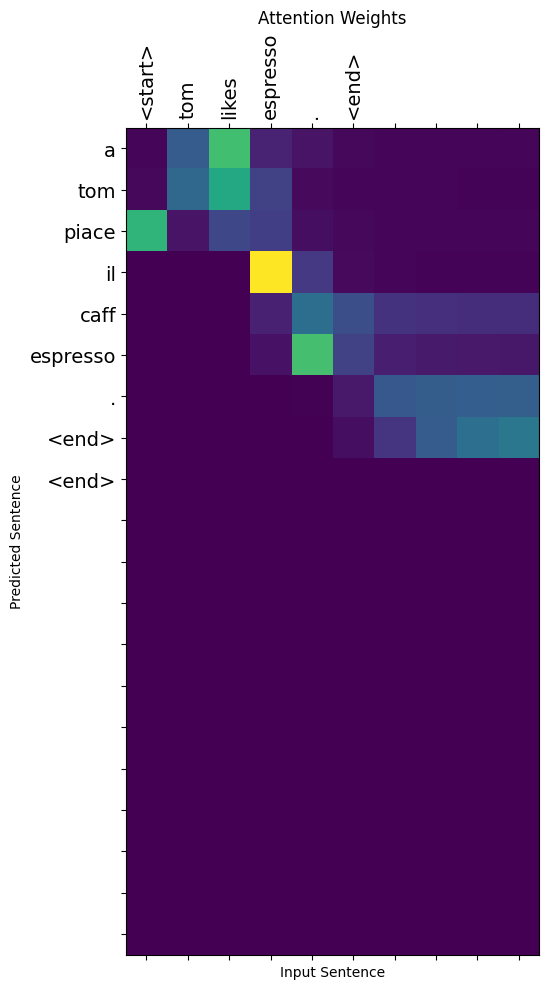

In [35]:
input_sentence = ' '.join([input_lang_tokenizer.index_word.get(idx, '<UNK>')
                            for idx in input_tensor_test[42] if idx != 0])
target_sentence = ' '.join([target_lang_tokenizer.index_word.get(idx, '<UNK>')
                            for idx in target_tensor_test[42] if idx != 0])
result, original_input, attention_plot = evaluate_model(input_sentence)
print(input_sentence.split(), target_sentence.split())
plot_attention(attention_plot, original_input.split(), result.split())

In [38]:
! pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00


In [ ]:
import re
import evaluate

def clean_sentence_for_bleu(sentence: str) -> str:
    cleaned = sentence.replace('<start>', '').replace('<end>', '').replace('<pad>', '').strip()
    cleaned = re.sub(r'\s+', ' ', cleaned)
    return cleaned

def calculate_metric_on_testset_with_bleu():
    try:
        references = []
        candidates = []

        num_examples_to_show = 5

        print("=================== BLEU Score Evaluation on Test Set ===================")
        print(f"Preparing to evaluate {num_examples_to_show} examples.")

        for i in range(len(input_tensor_test)):
            input_eng_tokens = [
                input_lang_tokenizer.index_word.get(idx, '<UNK>')
                for idx in input_tensor_test[i] if idx != 0 and idx != input_lang_tokenizer.word_index.get('<pad>', 0)
            ]
            target_ita_tokens = [
                target_lang_tokenizer.index_word.get(idx, '<UNK>')
                for idx in target_tensor_test[i] if idx != 0 and idx != target_lang_tokenizer.word_index.get('<pad>', 0)
            ]

            input_eng_sentence = ' '.join(input_eng_tokens)
            target_ita_sentence = ' '.join(target_ita_tokens)

            output_ita_sentence, _, _ = evaluate_model(input_eng_sentence)

            cleaned_reference = clean_sentence_for_bleu(target_ita_sentence)
            cleaned_candidate = clean_sentence_for_bleu(output_ita_sentence)

            references.append([cleaned_reference])
            candidates.append(cleaned_candidate)

        for i in range(num_examples_to_show):
            cleaned_reference = references[i][0]
            cleaned_candidate = candidates[i]
            input_eng_tokens = [
                input_lang_tokenizer.index_word.get(idx, '<UNK>')
                for idx in input_tensor_test[i] if idx != 0 and idx != input_lang_tokenizer.word_index.get('<pad>', 0)
            ]
            input_eng_sentence = ' '.join(input_eng_tokens)
            print("\n" + "="*50)
            print(f"TEST EXAMPLE # {i + 1}")
            print("🇮🇹 Target:   ", cleaned_reference)
            print("🇺🇸 Input:     ", input_eng_sentence)
            print("Translated: ", cleaned_candidate)


        if candidates:
            bleu = evaluate.load("bleu")
            results = bleu.compute(predictions=candidates, references=references)

            print("\n" + "="*60)
            print(f"Corpus BLEU score over {len(candidates)} examples: {results['bleu']:.4f}")
            print("="*60)

            return results['bleu']
        else:
            print("\nNo test examples were processed.")
            return 0.0

    except Exception as e:
        print(f">>> An exception occurred during BLEU evaluation: {e}")
        return -1

calculate_metric_on_testset_with_bleu()

=================== BLEU Score Evaluation on Test Set ===================
Preparing to evaluate 5 examples.

TEST EXAMPLE # 1
🇮🇹 Target:    siamo sbronzi .
🇺🇸 Input:      <start> we re smashed . <end>
Translated:  siamo ubriache .

TEST EXAMPLE # 2
🇮🇹 Target:    bello vedervi !
🇺🇸 Input:      <start> nice seeing you ! <end>
Translated:  bello vederla !

TEST EXAMPLE # 3
🇮🇹 Target:    non sembrare cos triste .
🇺🇸 Input:      <start> don t look so sad . <end>
Translated:  non sembrate cos tristi .

TEST EXAMPLE # 4
🇮🇹 Target:    tom ha visitato boston .
🇺🇸 Input:      <start> tom visited boston . <end>
Translated:  tom ha lasciato boston .

TEST EXAMPLE # 5
🇮🇹 Target:    li troveremo .
🇺🇸 Input:      <start> we ll find them . <end>
Translated:  noi li troveremo .


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Corpus BLEU score over 16800 examples: 0.4104


0.41041321344104326